# 1. The Single Crane Lift Sequence Problem

## Tier 2 — A Classic Heuristic (WSPT-inspired)

Exact methods can be expensive. In real terminals you often need a **fast, good-enough** rule.

This notebook implements a transparent greedy heuristic inspired by **Weighted Shortest Processing Time (WSPT)**.

### Learning goals

- See how to build a heuristic score that balances:
  - urgency (priority)
  - travel time
  - handling time
  - mode switching costs
- Understand why dual lifts can be beneficial even if they require a setup.

### What you get

- A complete step-by-step schedule for an 8-container example
- A total completion time
- A visualization that makes the sequence easy to understand


In [1]:
# Environment check (no installs here)
#
# Best practice for classes: preinstall dependencies in the Docker/JupyterHub image.
# If you're running locally, install packages once in your environment.

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "Missing dependency. Install: numpy, pandas, matplotlib. "
        "If you use the provided JupyterHub Docker image, these should already be installed."
    ) from e

print("Dependencies imported successfully.")


Dependencies imported successfully.


## Concrete example instance (8 containers)

We use a small 2×4 bay. Each container has:

- `weight` (tons)
- `priority` (higher means more urgent)
- a fixed grid location

### Time model (simplified but instructive)

- **Travel time** is proportional to Manhattan distance on the grid.
- **Single lift** moves to one container and handles it.
- **Dual lift** moves to the *center* of two adjacent containers and handles both at once.
- Switching between single/dual modes costs a fixed **setup time**.

### Dual feasibility

A dual lift is allowed if:

- The two containers are adjacent on the grid.
- Their combined weight is at most the dual limit.


In [2]:
# ----------------------------
# Imports + data definition (Tier 2)
# ----------------------------
# In this cell we define:
# - the container data
# - the time model
# - helper functions (distance, travel time)
# - which pairs are eligible for a dual lift

from dataclasses import dataclass
from itertools import combinations
from typing import List, Tuple, Literal, Dict, Any, Set, Optional
import ast


# ----------------------------
# Small type alias
# ----------------------------
# We'll use these exact strings to represent the crane mode.
Mode = Literal["single", "dual"]


# ----------------------------
# Container data class
# ----------------------------
# `rc` is a (row, col) coordinate in a 2x4 grid.
@dataclass(frozen=True)
class Container:
    id: int
    rc: Tuple[int, int]  # (row, col)
    weight: float
    priority: int


# ----------------------------
# Concrete example instance
# ----------------------------
# We place 8 containers on a 2x4 grid.
# Higher `priority` => more urgent.
containers: List[Container] = [
    Container(1, (0, 0), 8.5, 3),
    Container(2, (0, 1), 12.3, 2),
    Container(3, (0, 2), 15.7, 4),
    Container(4, (0, 3), 9.8, 3),
    Container(5, (1, 0), 11.2, 2),
    Container(6, (1, 1), 14.1, 2),
    Container(7, (1, 2), 13.9, 1),
    Container(8, (1, 3), 10.6, 2),
]

# Map id -> container for quick lookup
id_to_container = {c.id: c for c in containers}


# ----------------------------
# Parameters (minutes)
# ----------------------------
HANDLE_SINGLE = 2.5
HANDLE_DUAL = 3.8
SETUP_TIME = 1.2
DUAL_WEIGHT_LIMIT = 20.0
TRAVEL_PER_GRID_STEP = 0.8

# Initial crane state
START_RC = (0, 0)
START_MODE: Mode = "single"


# ----------------------------
# Geometry helpers
# ----------------------------
# Manhattan distance is common on grid-like movement.
# Example: distance between (0,0) and (1,2) is |0-1| + |0-2| = 3.
def manhattan(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


# Convert distance into time by multiplying with a constant.
def travel_time(a: Tuple[float, float], b: Tuple[float, float]) -> float:
    return TRAVEL_PER_GRID_STEP * manhattan(a, b)


# Two cells are adjacent if they are 1 step apart in Manhattan distance.
def adjacent_int(a: Tuple[int, int], b: Tuple[int, int]) -> bool:
    return abs(a[0] - b[0]) + abs(a[1] - b[1]) == 1


# Dual is feasible if:
# - two containers are adjacent
# - combined weight <= limit
# This mimics: dual spreader can only lift adjacent boxes and has a max capacity.
def dual_feasible(i: int, j: int) -> bool:
    ci, cj = id_to_container[i], id_to_container[j]
    return adjacent_int(ci.rc, cj.rc) and (ci.weight + cj.weight) <= DUAL_WEIGHT_LIMIT


# Center position for dual lift = average of the two coordinates.
# We use floats because centers can be half-integers.
def dual_center(ci: Container, cj: Container) -> Tuple[float, float]:
    return ((ci.rc[0] + cj.rc[0]) / 2.0, (ci.rc[1] + cj.rc[1]) / 2.0)


# Precompute all feasible dual pairs for this instance.
dual_pairs = []
for i, j in combinations([c.id for c in containers], 2):
    if dual_feasible(i, j):
        dual_pairs.append((i, j))

dual_pairs

[(1, 5)]

## Heuristic logic (greedy decision at each step)

At each iteration we compare:

- The best **single** lift (highest score)
- The best **dual** lift (highest score among feasible pairs)

### Scoring idea

A lift is attractive if it has high priority and low time cost.

- Single score:

`priority / (travel + single_handle + ε)`

- Dual score:

`avg_priority / (travel_to_center + setup_if_needed + dual_handle + ε)`

### Decision rule

If the best dual score is close enough to the best single score (threshold), we take the dual lift; otherwise we take the single lift.

This is a deliberately simple rule so you can understand exactly *why* each decision was made.


In [3]:
# ----------------------------
# Greedy heuristic implementation
# ----------------------------
# We implement two subroutines:
# - `best_single`: among remaining containers, pick the best *single* lift
# - `best_dual`: among remaining containers, pick the best *dual* lift
#
# Then `run_heuristic` repeatedly selects either single or dual until done.


def best_single(remaining: Set[int], crane_rc: Tuple[float, float]) -> Tuple[int, float]:
    """Return (container_id, score) for the best single-lift candidate."""

    # Small constant to avoid dividing by zero.
    eps = 1e-9

    best_id: Optional[int] = None
    best_score = -1.0

    for cid in remaining:
        c = id_to_container[cid]

        # Convert integer cell coordinate into float coordinate for consistent typing.
        target = (float(c.rc[0]), float(c.rc[1]))

        # Heuristic idea: higher priority is good, high time cost is bad.
        # So we use priority / (time_cost).
        time_cost = travel_time(crane_rc, target) + HANDLE_SINGLE
        score = c.priority / (time_cost + eps)

        if score > best_score:
            best_score = score
            best_id = cid

    assert best_id is not None
    return best_id, float(best_score)


def best_dual(
    remaining: Set[int],
    crane_rc: Tuple[float, float],
    crane_mode: Mode,
) -> Tuple[Optional[Tuple[int, int]], float]:
    """Return (pair, score) for the best feasible dual-lift candidate.

    If no dual lift is feasible, returns (None, -1).
    """

    eps = 1e-9

    best_pair: Optional[Tuple[int, int]] = None
    best_score = -1.0

    # Iterate over all unordered pairs from `remaining`.
    for i, j in combinations(sorted(remaining), 2):
        if not dual_feasible(i, j):
            continue

        ci, cj = id_to_container[i], id_to_container[j]

        # Dual target = center point between two containers.
        ctr = dual_center(ci, cj)

        # Pay setup cost if we are not currently in dual mode.
        setup = SETUP_TIME if crane_mode != "dual" else 0.0

        # We combine two priorities by averaging.
        avg_priority = (ci.priority + cj.priority) / 2.0

        # Total time denominator includes:
        # - travel to center
        # - setup (maybe)
        # - dual handling time
        time_cost = travel_time(crane_rc, ctr) + setup + HANDLE_DUAL
        score = avg_priority / (time_cost + eps)

        if score > best_score:
            best_score = score
            best_pair = (i, j)

    return best_pair, float(best_score)


def run_heuristic(threshold: float = 0.9) -> Tuple[pd.DataFrame, float]:
    """Run the greedy heuristic and return (step_table, total_time).

    `threshold` controls how willing we are to choose a dual lift.
    - If threshold is close to 1.0, we choose dual only when it is nearly as good as single.
    - If threshold is smaller, we choose dual more often.

    Pedagogical note:
    - Setting threshold to 0.0 forces the rule to take a dual lift whenever one is feasible.
      This is useful to *show* dual-lift behavior, even if it is not competitive under realistic settings.
    """

    # Remaining container IDs
    remaining = set(c.id for c in containers)

    # Current crane state
    rc: Tuple[float, float] = (float(START_RC[0]), float(START_RC[1]))
    mode: Mode = START_MODE

    # We'll store step-by-step logs here.
    steps: List[Dict[str, Any]] = []
    total = 0.0

    # Repeat until all containers are lifted.
    while remaining:
        # Best single option right now
        sid, sscore = best_single(remaining, rc)

        # Best dual option right now
        dpair, dscore = best_dual(remaining, rc, mode)

        # Decision: choose dual if it is "close enough" to single.
        choose_dual = dpair is not None and dscore >= threshold * sscore

        if choose_dual:
            # ----------------------------
            # Execute a dual lift
            # ----------------------------
            i, j = dpair
            ci, cj = id_to_container[i], id_to_container[j]
            ctr = dual_center(ci, cj)

            # Setup cost only if we are switching mode.
            setup = SETUP_TIME if mode != "dual" else 0.0

            # Travel time to the center
            t = travel_time(rc, ctr)

            # Total time for this step
            step_time = t + setup + HANDLE_DUAL

            # Log the step
            steps.append(
                {
                    "type": "dual",
                    "containers": f"{i},{j}",
                    "to": f"center({ctr[0]:.1f},{ctr[1]:.1f})",
                    "travel": t,
                    "setup": setup,
                    "handle": HANDLE_DUAL,
                    "step_time": step_time,
                }
            )

            # Update total and state
            total += step_time
            remaining -= {i, j}
            rc = ctr
            mode = "dual"

        else:
            # ----------------------------
            # Execute a single lift
            # ----------------------------
            c = id_to_container[sid]
            target = (float(c.rc[0]), float(c.rc[1]))

            # Setup cost only if we are switching mode.
            setup = SETUP_TIME if mode != "single" else 0.0

            # Travel time to the container cell
            t = travel_time(rc, target)

            # Total time for this step
            step_time = t + setup + HANDLE_SINGLE

            # Log the step
            steps.append(
                {
                    "type": "single",
                    "containers": f"{sid}",
                    "to": str(c.rc),
                    "travel": t,
                    "setup": setup,
                    "handle": HANDLE_SINGLE,
                    "step_time": step_time,
                }
            )

            # Update total and state
            total += step_time
            remaining.remove(sid)
            rc = target
            mode = "single"

    # ----------------------------
    # Turn logs into a table
    # ----------------------------
    df = pd.DataFrame(steps)

    # Start index at 1 for nicer display
    df.index = np.arange(1, len(df) + 1)

    # Round numeric columns
    for col in ["travel", "setup", "handle", "step_time"]:
        df[col] = df[col].astype(float).round(3)

    return df, float(total)


# Run the heuristic once (default threshold)
# You can try other thresholds (e.g., 0.8 or 0.95) and see how behavior changes.
df_steps, total_time = run_heuristic(threshold=0.9)
print(f"Total heuristic time: {total_time:.3f} min")

# Pedagogical check: did we actually use any dual steps?
num_dual = int((df_steps["type"] == "dual").sum())
print(f"Dual steps used (threshold=0.9): {num_dual}")

df_steps

# ----------------------------
# Sensitivity: threshold and dual weight limit
# ----------------------------
# If dual steps never appear, it is often because:
# - the threshold is too strict, OR
# - dual feasibility is too restrictive (weight limit), OR
# - dual pairs exist but are rarely competitive given setup cost.

thresholds = [0.95, 0.9, 0.85, 0.8, 0.7, 0.0]
rows = []
for th in thresholds:
    df_th, t_th = run_heuristic(threshold=th)
    rows.append(
        {
            "threshold": float(th),
            "total_time": float(t_th),
            "dual_steps": int((df_th["type"] == "dual").sum()),
        }
    )

print("\nSensitivity over threshold (fixed weight limit):")
pd.DataFrame(rows)


def run_with_dual_limit(limit: float, threshold: float) -> Dict[str, Any]:
    global DUAL_WEIGHT_LIMIT

    old = float(DUAL_WEIGHT_LIMIT)
    DUAL_WEIGHT_LIMIT = float(limit)

    df_lim, t_lim = run_heuristic(threshold=threshold)

    out = {
        "dual_weight_limit": float(limit),
        "threshold": float(threshold),
        "total_time": float(t_lim),
        "dual_steps": int((df_lim["type"] == "dual").sum()),
    }

    DUAL_WEIGHT_LIMIT = old
    return out


limits = [20.0, 22.0, 24.0, 26.0, 30.0]

print("\nSensitivity over dual weight limit (threshold fixed at 0.85):")
rows2 = [run_with_dual_limit(L, threshold=0.85) for L in limits]
pd.DataFrame(rows2)

print("\nSensitivity over dual weight limit (threshold fixed at 0.0 to force dual when feasible):")
rows3 = [run_with_dual_limit(L, threshold=0.0) for L in limits]
pd.DataFrame(rows3)

Total heuristic time: 28.800 min
Dual steps used (threshold=0.9): 0

Sensitivity over threshold (fixed weight limit):

Sensitivity over dual weight limit (threshold fixed at 0.85):

Sensitivity over dual weight limit (threshold fixed at 0.0 to force dual when feasible):


,dual_weight_limit,threshold,total_time,dual_steps
0,20.0,0.0,29.2,1
1,22.0,0.0,28.0,2
2,24.0,0.0,28.0,2
3,26.0,0.0,22.4,4
4,30.0,0.0,22.4,4


## Visualization

The diagram below is meant to help a student visually connect:

- where each container is
- what the crane does step-by-step

Tip: after looking at the arrows, compare with the schedule table above.


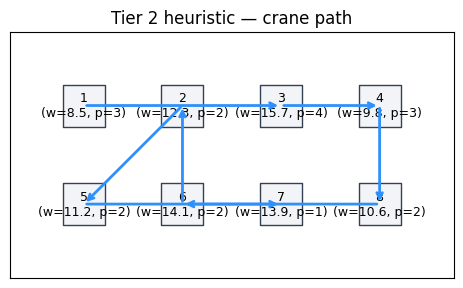

In [4]:
# ----------------------------
# Visualization (beginner-friendly)
# ----------------------------
# We will:
# 1) draw the 2x4 grid
# 2) place container labels
# 3) draw arrows following the chosen schedule

fig, ax = plt.subplots(figsize=(7, 3.2))

# ----------------------------
# Draw grid cells
# ----------------------------
for r in [0, 1]:
    for c in [0, 1, 2, 3]:
        ax.scatter(
            [c],
            [-r],
            s=900,
            marker="s",
            facecolor="#F2F4F7",
            edgecolor="#344054",
        )

# ----------------------------
# Draw container labels
# ----------------------------
for cont in containers:
    x, y = cont.rc[1], -cont.rc[0]
    ax.text(
        x,
        y,
        f"{cont.id}\n(w={cont.weight}, p={cont.priority})",
        ha="center",
        va="center",
        fontsize=9,
    )

# ----------------------------
# Build the crane path list
# ----------------------------
# Start point
path = [(START_RC[1], -START_RC[0])]

# For each step, parse the target and append it.
for _, row in df_steps.iterrows():
    if row["type"] == "single":
        # `to` is like "(0, 2)" so we parse it safely.
        target = ast.literal_eval(row["to"])
        path.append((target[1], -target[0]))
    else:
        # `to` is like "center(0.5,1.0)" so we parse the numbers.
        s = row["to"]
        inside = s[s.find("(") + 1 : s.find(")")]
        rr, cc = [float(x) for x in inside.split(",")]
        path.append((cc, -rr))

# ----------------------------
# Draw arrows between consecutive path points
# ----------------------------
for (x1, y1), (x2, y2) in zip(path[:-1], path[1:]):
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=2, color="#2E90FA"),
    )

# Final formatting
ax.set_title("Tier 2 heuristic — crane path")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.75, 3.75)
ax.set_ylim(-1.75, 0.75)
ax.set_aspect("equal")

plt.show()

## Additional operational visualizations (logistics-focused)

The bay/path plot is helpful, but in logistics we also care about:

- where time is spent (**travel vs setup vs handling**)
- how total completion time grows step-by-step (**cumulative time**)
- a simple operations timeline (**Gantt-like view**)

The following plots are derived directly from the schedule table above.

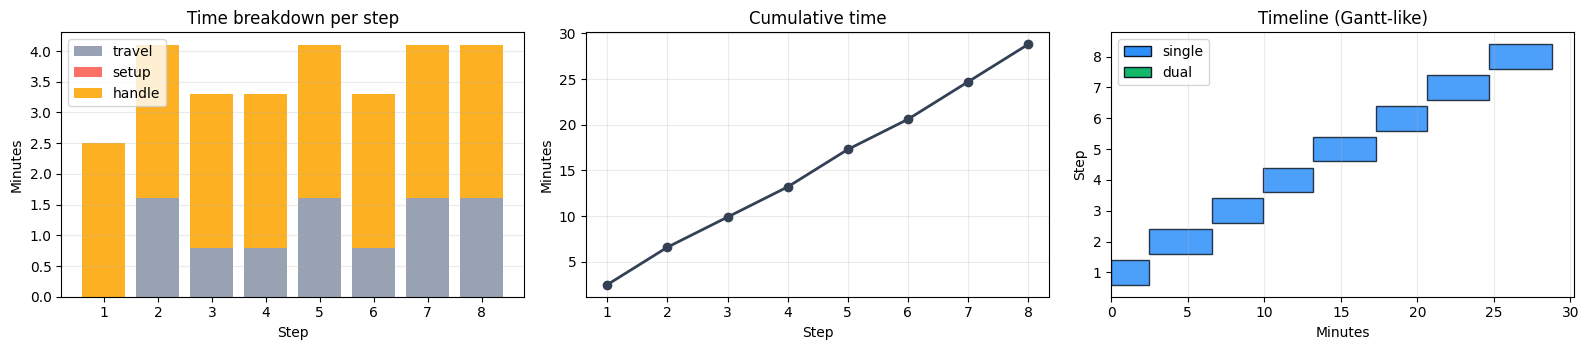

In [5]:
# ----------------------------
# Operational visualizations from the schedule table
# ----------------------------
# These plots are very common in logistics / terminal operations analysis:
# - time breakdown: where do we spend time?
# - cumulative time: how does total completion time accumulate?
# - simple timeline (Gantt-like): sequence of actions over time

# Make sure the table is in a clean numeric form
vis = df_steps.copy()
vis["step"] = vis.index.astype(int)

# Cumulative time after each step
vis["cum_time"] = vis["step_time"].cumsum()

# For Gantt-like timeline we need each step's start time
vis["start_time"] = vis["cum_time"] - vis["step_time"]

# Colors by action type
color_map = {"single": "#2E90FA", "dual": "#12B76A"}
colors = [color_map[t] for t in vis["type"].tolist()]

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))

# ----------------------------
# (1) Stacked bar: travel/setup/handle breakdown
# ----------------------------
axes[0].bar(vis["step"], vis["travel"], label="travel", color="#98A2B3")
axes[0].bar(vis["step"], vis["setup"], bottom=vis["travel"], label="setup", color="#F97066")
axes[0].bar(
    vis["step"],
    vis["handle"],
    bottom=vis["travel"] + vis["setup"],
    label="handle",
    color="#FDB022",
)
axes[0].set_title("Time breakdown per step")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Minutes")
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].legend()

# ----------------------------
# (2) Cumulative completion time
# ----------------------------
axes[1].plot(vis["step"], vis["cum_time"], marker="o", lw=2, color="#344054")
axes[1].set_title("Cumulative time")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Minutes")
axes[1].grid(True, alpha=0.25)

# ----------------------------
# (3) Timeline / Gantt-like view
# ----------------------------
# Each bar shows the time interval [start_time, start_time + step_time)
axes[2].barh(
    y=vis["step"],
    width=vis["step_time"],
    left=vis["start_time"],
    color=colors,
    edgecolor="#101828",
    alpha=0.85,
)
axes[2].set_title("Timeline (Gantt-like)")
axes[2].set_xlabel("Minutes")
axes[2].set_ylabel("Step")
axes[2].grid(True, axis="x", alpha=0.25)

# Create a small legend for single vs dual
from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color_map["single"], edgecolor="#101828", label="single"),
    Patch(facecolor=color_map["dual"], edgecolor="#101828", label="dual"),
]
axes[2].legend(handles=legend_handles, loc="best")

plt.tight_layout()
plt.show()

## Why this Tier exists vs earlier Tiers (comparison)

### Why Tier 2 exists (vs Tier 1)

Tier 1 used **dynamic programming** to find an *optimal* plan for a small instance. That is great for correctness and learning, but DP grows quickly as the number of containers increases.

Tier 2 exists because in real operations you often want a solution that is:

- fast to compute
- easy to explain to operators
- “good enough” most of the time

### Advantages vs Tier 1

- Much faster for larger instances (greedy decisions instead of exploring many states)
- Simple to implement and adjust (change a score or threshold)
- Produces a complete schedule immediately

### Disadvantages vs Tier 1

- Not guaranteed to be optimal
- Quality depends on the chosen scoring rule and threshold
- Can get trapped in short-sighted choices (local decisions that look good now but hurt later)

### When to use Tier 2

- You need a quick schedule in seconds
- Instance is large enough that exact optimization is too slow
- You want an interpretable baseline before trying more advanced methods
